In [17]:
import numpy as np
import pandas as pd
import yfinance as yf

import scipy.stats as stats
from scipy.stats import jarque_bera, norm, t

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [18]:
ticker = "^NSEI"

data = yf.download(
    ticker,
    start="2010-01-01",
    end="2025-06-01",
    auto_adjust=True
)

prices = data["Close"].squeeze()

returns = np.log(prices / prices.shift(1)).dropna()

print("Observations:", len(returns))
returns.head()

[*********************100%***********************]  1 of 1 completed

Observations: 3781


Date
2010-01-05    0.008696
2010-01-06    0.000739
2010-01-07   -0.003547
2010-01-08   -0.003493
2010-01-11    0.000886
Name: ^NSEI, dtype: float64

In [ ]:
import os

FIG_DIR = "report_assets"

os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIG_DIR, name),
        dpi=300,
        bbox_inches="tight"
    )

In [20]:
mean_ret = returns.mean()
std_ret = returns.std()

skewness = stats.skew(returns)
kurtosis = stats.kurtosis(returns, fisher=False)

jb_stat, jb_p = jarque_bera(returns)

print(f"Mean Return      : {mean_ret:.6f}")
print(f"Std Dev          : {std_ret:.6f}")
print(f"Skewness         : {skewness:.3f}")
print(f"Kurtosis         : {kurtosis:.3f}")
print(f"JB Statistic     : {jb_stat:.2f}")
print(f"JB p-value       : {jb_p:.5e}")

Mean Return      : 0.000411
Std Dev          : 0.010588
Skewness         : -0.906
Kurtosis         : 16.351
JB Statistic     : 28597.99
JB p-value       : 0.00000e+00


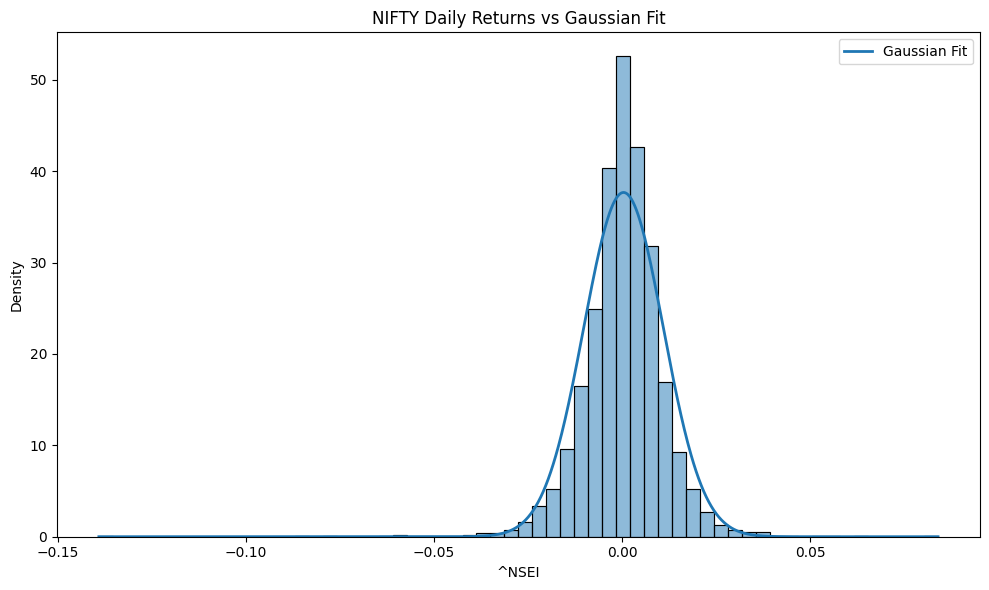

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    returns,
    bins=60,
    stat='density',
    alpha=0.5
)

x = np.linspace(
    returns.min(),
    returns.max(),
    1000
)

plt.plot(
    x,
    norm.pdf(x, mean_ret, std_ret),
    linewidth=2,
    label='Gaussian Fit'
)
plt.legend()
plt.title("NIFTY Daily Returns vs Gaussian Fit")

savefig("01_histogram_gaussian_fit.png")

plt.show()

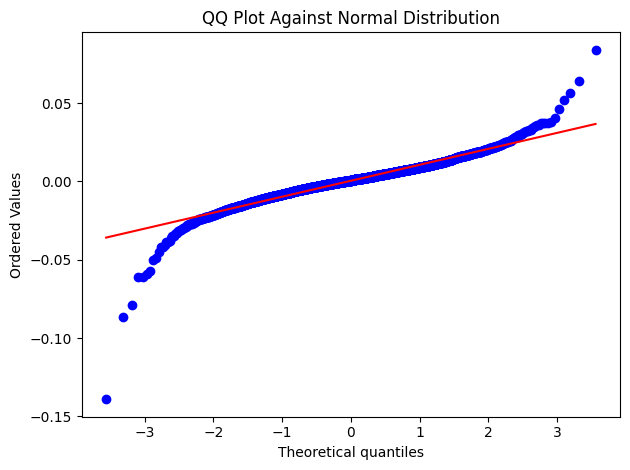

In [22]:
stats.probplot(
    returns.squeeze(),
    dist="norm",
    plot=plt
)

plt.title("QQ Plot Against Normal Distribution")

savefig("02_qq_plot_normality.png")

plt.show()

In [23]:
df_t, loc_t, scale_t = t.fit(returns)

print("Student-t parameters")
print("Degrees of freedom:", round(df_t,2))
print("Location:", round(loc_t,6))
print("Scale:", round(scale_t,6))

Student-t parameters
Degrees of freedom: 4.07
Location: 0.000649
Scale: 0.007473


In [24]:
gaussian_ll = np.sum(
    norm.logpdf(
        returns,
        mean_ret,
        std_ret
    )
)

student_ll = np.sum(
    t.logpdf(
        returns,
        df_t,
        loc_t,
        scale_t
    )
)

print("Gaussian Log Likelihood :", round(gaussian_ll,2))
print("Student-t Log Likelihood:", round(student_ll,2))
print("Improvement:", round(student_ll-gaussian_ll,2))

Gaussian Log Likelihood : 11831.64
Student-t Log Likelihood: 12173.57
Improvement: 341.93


In [25]:
z = (returns - mean_ret) / std_ret

for k in [3,4,5]:

    observed = np.sum(np.abs(z) > k)

    expected = len(z) * (
        2 * (1 - norm.cdf(k))
    )

    ratio = observed / max(expected,1e-10)

    print("\nThreshold:",k,"sigma")
    print("Observed :", observed)
    print("Expected :", round(expected,2))
    print("Ratio    :", round(ratio,2))


Threshold: 3 sigma
Observed : 43
Expected : 10.21
Ratio    : 4.21

Threshold: 4 sigma
Observed : 15
Expected : 0.24
Ratio    : 62.63

Threshold: 5 sigma
Observed : 10
Expected : 0.0
Ratio    : 4613.27


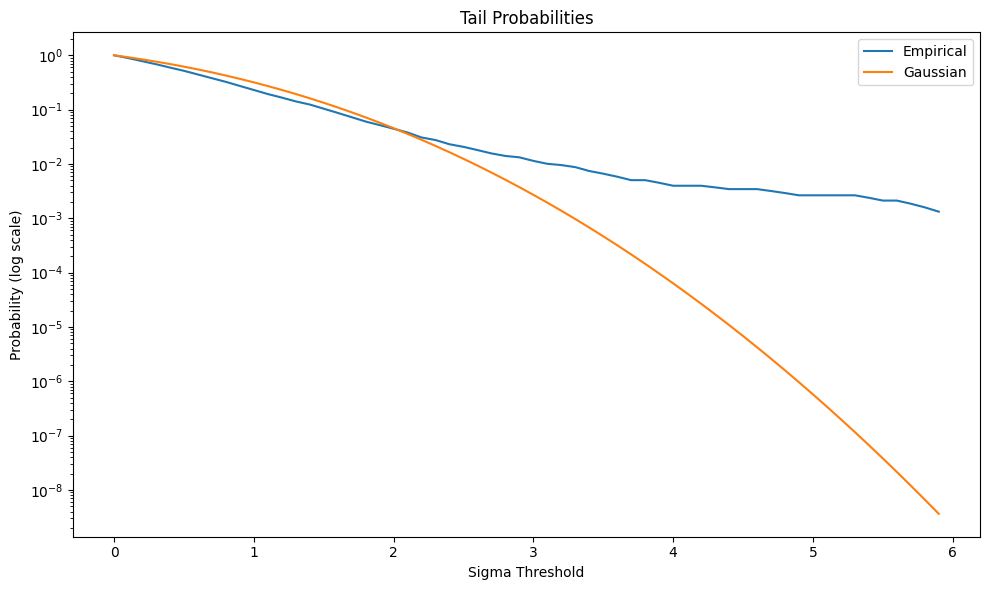

In [26]:
thresholds = np.arange(0,6,0.1)

empirical = [
    np.mean(np.abs(z)>x)
    for x in thresholds
]

gaussian = [
    2*(1-norm.cdf(x))
    for x in thresholds
]

plt.figure(figsize=(10,6))

plt.semilogy(
    thresholds,
    empirical,
    label='Empirical'
)

plt.semilogy(
    thresholds,
    gaussian,
    label='Gaussian'
)

plt.legend()
plt.title("Tail Probabilities")
plt.xlabel("Sigma Threshold")
plt.ylabel("Probability (log scale)")

savefig("03_tail_probability_comparison.png")

plt.show()

In [27]:
print("="*50)
print("FINAL RESULTS")
print("="*50)

print(f"Observations: {len(returns)}")
print(f"Skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")
print(f"Jarque-Bera p-value: {jb_p:.5e}")

print(f"Gaussian LL: {gaussian_ll:.2f}")
print(f"Student-t LL: {student_ll:.2f}")

for k in [3,4,5]:

    observed = np.sum(np.abs(z)>k)

    expected = len(z)*(2*(1-norm.cdf(k)))

    ratio = observed/max(expected,1e-10)

    print(
        f"{k}σ -> Observed={observed}, Expected={expected:.2f}, Ratio={ratio:.2f}"
    )

FINAL RESULTS
Observations: 3781
Skewness: -0.906
Kurtosis: 16.351
Jarque-Bera p-value: 0.00000e+00
Gaussian LL: 11831.64
Student-t LL: 12173.57
3σ -> Observed=43, Expected=10.21, Ratio=4.21
4σ -> Observed=15, Expected=0.24, Ratio=62.63
5σ -> Observed=10, Expected=0.00, Ratio=4613.27


In [28]:
print(df_t)

4.073685074611851


In [29]:
returns_df = pd.DataFrame({"ret": returns})

crisis = returns_df.loc["2020-01-01":"2020-12-31"]
non_crisis = returns_df.drop(crisis.index)

print("Crisis Kurtosis:", stats.kurtosis(crisis["ret"], fisher=False))
print("Non-Crisis Kurtosis:", stats.kurtosis(non_crisis["ret"], fisher=False))

Crisis Kurtosis: 15.390887469945296
Non-Crisis Kurtosis: 5.474927875512201


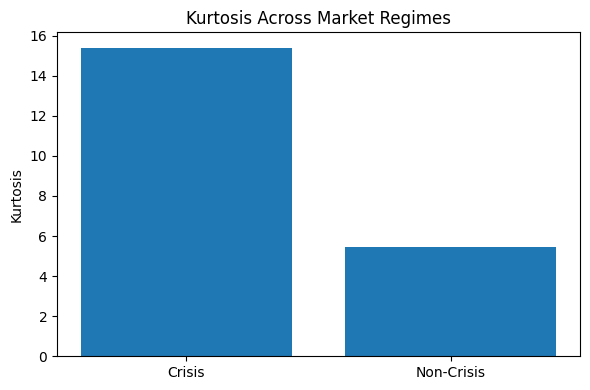

In [30]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Crisis", "Non-Crisis"],
    [
        stats.kurtosis(crisis["ret"], fisher=False),
        stats.kurtosis(non_crisis["ret"], fisher=False)
    ]
)

plt.ylabel("Kurtosis")
plt.title("Kurtosis Across Market Regimes")

savefig("04_crisis_vs_noncrisis_kurtosis.png")

plt.show()

In [31]:
from scipy.stats import anderson

result = anderson(returns, dist='norm')

print(result.statistic)
print(result.critical_values)

33.11925189633121
[0.575 0.655 0.786 0.917 1.091]


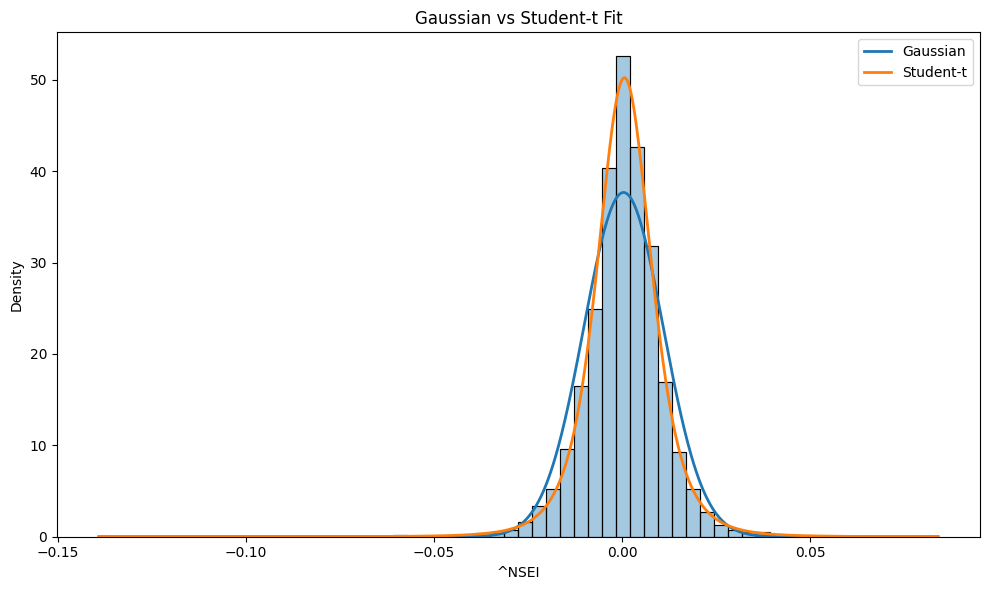

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(
    returns,
    stat='density',
    bins=60,
    alpha=0.4
)

x = np.linspace(
    returns.min(),
    returns.max(),
    1000
)

plt.plot(
    x,
    norm.pdf(x, mean_ret, std_ret),
    label='Gaussian',
    linewidth=2
)

plt.plot(
    x,
    t.pdf(x, df_t, loc_t, scale_t),
    label='Student-t',
    linewidth=2
)

plt.legend()
plt.title("Gaussian vs Student-t Fit")

savefig("05_gaussian_vs_student_t_fit.png")

plt.show()